# Importar bibliotecas y cargar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
%pip install -U scikit-learn

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df_raw = pd.read_csv(
        url,
        storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df_raw = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df_raw.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [5]:
df_raw = df_raw.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df_raw["births"] = df_raw["births_estimates"].fillna(df_raw["births_projected"])
df_raw["deaths"] = df_raw["deaths_estimates"].fillna(df_raw["deaths_projected"])

df_raw.head(3)

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0


In [6]:
def entrenar_y_graficar(df_pais, titulo_pais, anio_corte=2023):
    df_hist = df_pais[df_pais["Year"] <= anio_corte].copy()
    df_proy = df_pais[df_pais["Year"] > anio_corte].copy()

    X = df_hist[["Year"]]
    anios_futuros_np = np.arange(anio_corte + 1, 2101).reshape(-1, 1)
    X_futuro = pd.DataFrame(anios_futuros_np, columns=["Year"])

    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X)
    X_futuro_poly = poly.transform(X_futuro)

    for variable, label_var in [("births", "Nacimientos"), ("deaths", "Defunciones")]:
        y = df_hist[variable]

        rl = LinearRegression()
        rl.fit(X, y)
        pred_rl_hist = rl.predict(X)
        pred_rl_fut  = rl.predict(X_futuro)

        rp = LinearRegression()
        rp.fit(X_poly, y)
        pred_rp_hist = rp.predict(X_poly)
        pred_rp_fut  = rp.predict(X_futuro_poly)

        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        pred_rf_hist = rf.predict(X)
        pred_rf_fut  = rf.predict(X_futuro)

        anios_flat = anios_futuros_np.flatten()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
        fig.suptitle(f"{titulo_pais} – {label_var}", fontsize=14, fontweight="bold")

        modelos_info = [
            ("Regresión Lineal",     "tab:orange", pred_rl_hist,  pred_rl_fut),
            ("Regresión Polinomial", "tab:green",  pred_rp_hist,  pred_rp_fut),
            ("Random Forest",        "tab:red",    pred_rf_hist,  pred_rf_fut),
        ]

        for ax, (nombre, color, pred_hist, pred_fut) in zip(axes, modelos_info):
            ax.scatter(df_hist["Year"], df_hist[variable], label="Datos históricos", alpha=0.5, s=20)
            ax.plot(df_hist["Year"], pred_hist, color=color, label=f"{nombre} (ajuste)")
            ax.plot(anios_flat, pred_fut, color=color, linestyle="--", label=f"{nombre} (proyección)")
            if not df_proy.empty:
                ax.plot(df_proy["Year"], df_proy[variable], color="black", linewidth=2, label="Proyección OWID")
            ax.set_title(nombre)
            ax.set_xlabel("Año")
            ax.set_ylabel(label_var)
            ax.ticklabel_format(style="plain", axis="y", useOffset=False)
            ax.legend(fontsize=7)
            ax.grid(True)

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(14, 6))
        plt.scatter(df_hist["Year"], df_hist[variable], label="Datos históricos", alpha=0.5, s=20)
        if not df_proy.empty:
            plt.plot(df_proy["Year"], df_proy[variable], color="black", linewidth=2.5, label="Proyección OWID")
        plt.plot(anios_flat, pred_rl_fut,  color="tab:orange", label="Regresión Lineal")
        plt.plot(anios_flat, pred_rp_fut,  color="tab:green",  label="Regresión Polinomial")
        plt.plot(anios_flat, pred_rf_fut,  color="tab:red",    label="Random Forest")
        plt.title(f"{titulo_pais} – Comparación de modelos: {label_var}")
        plt.xlabel("Año")
        plt.ylabel(label_var)
        plt.ticklabel_format(style="plain", axis="y", useOffset=False)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Entidad China

In [7]:
df_china = df_raw[df_raw["Entity"] == "China"].copy()
df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


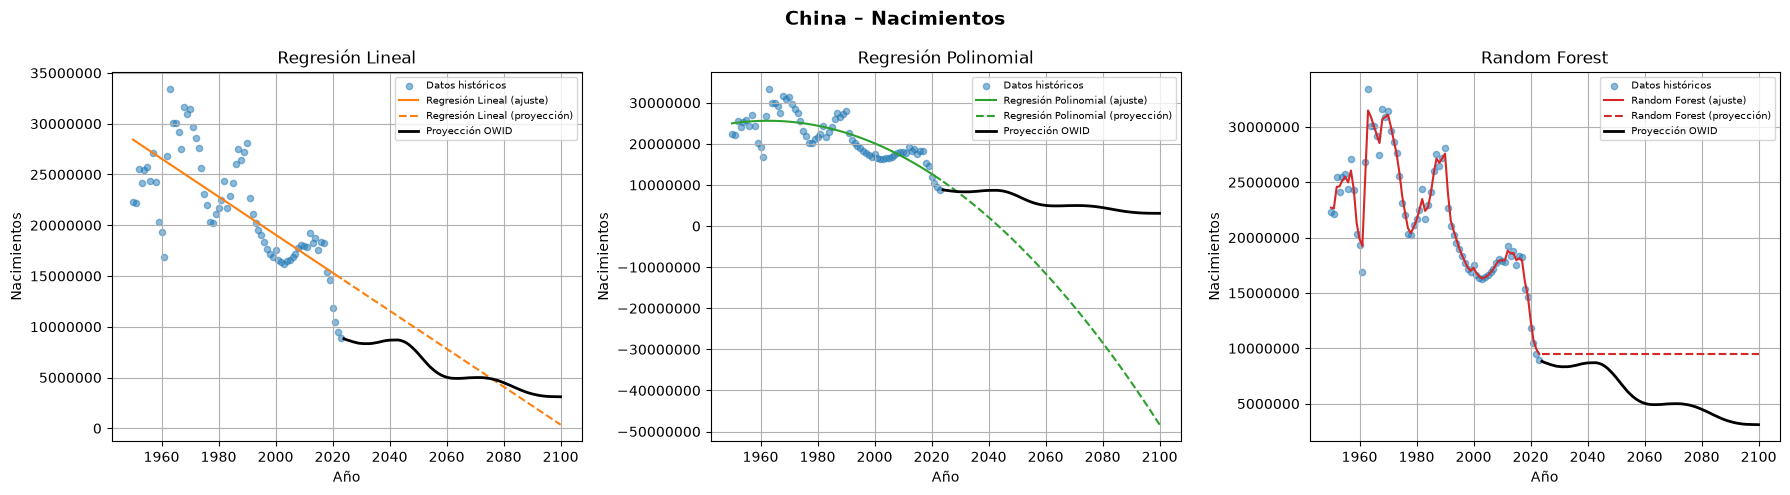

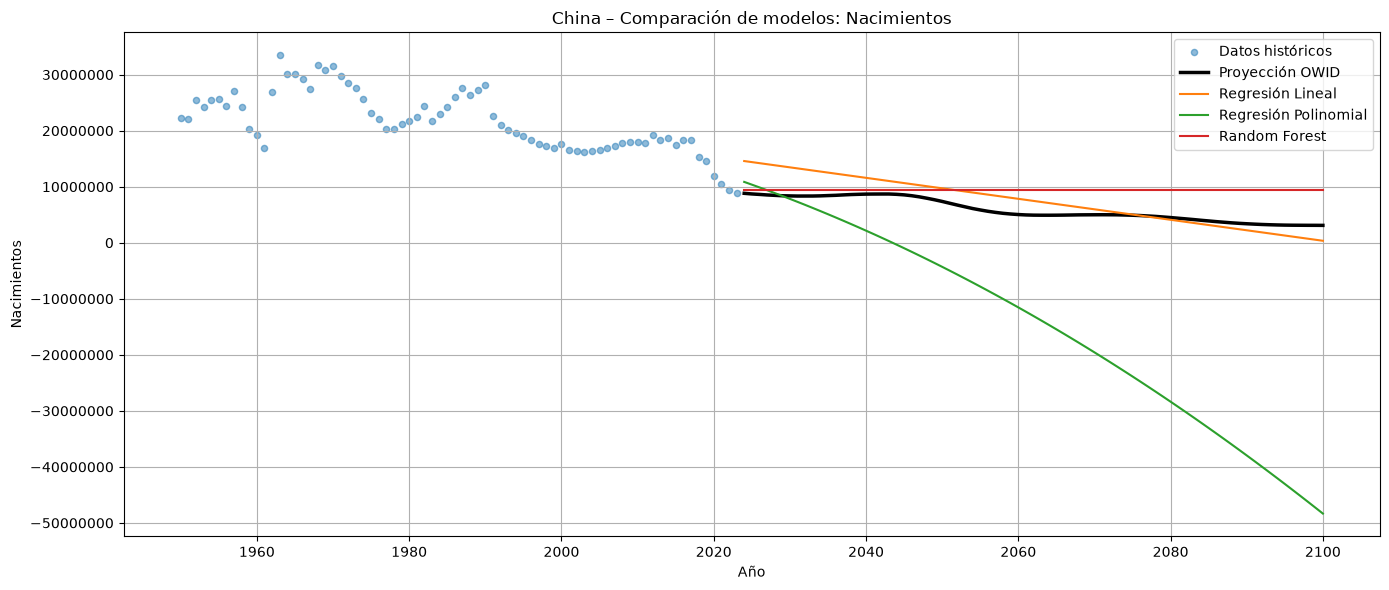

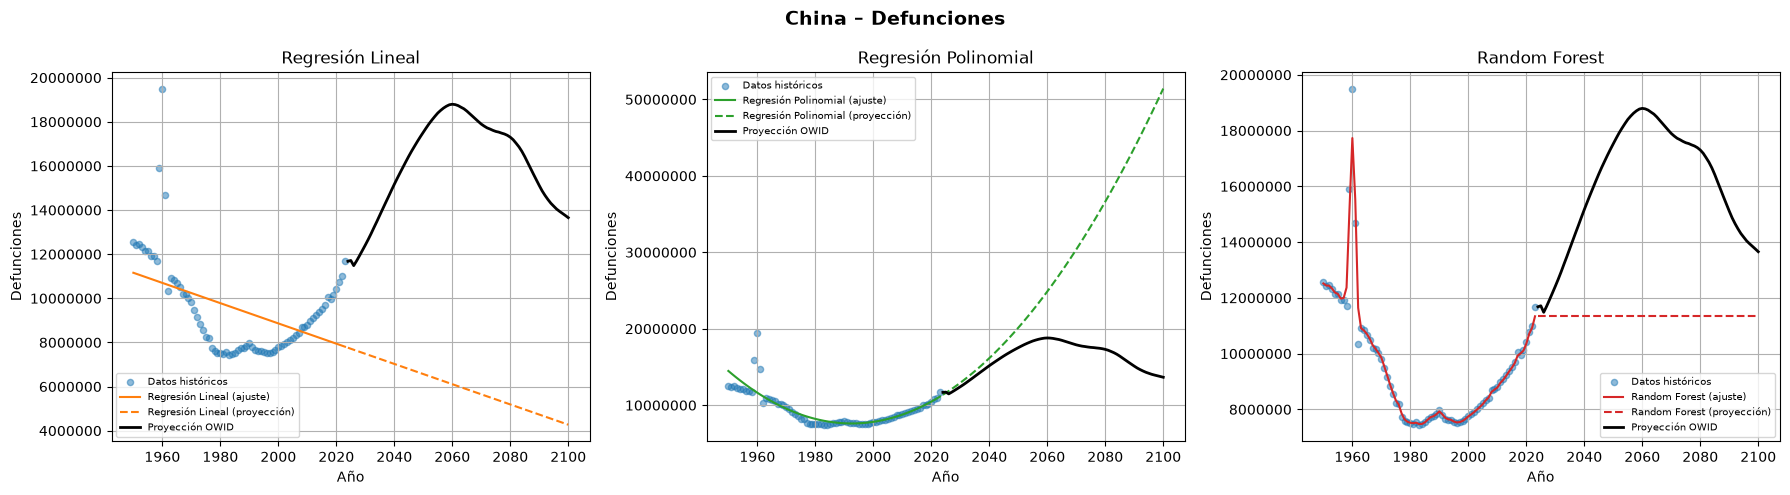

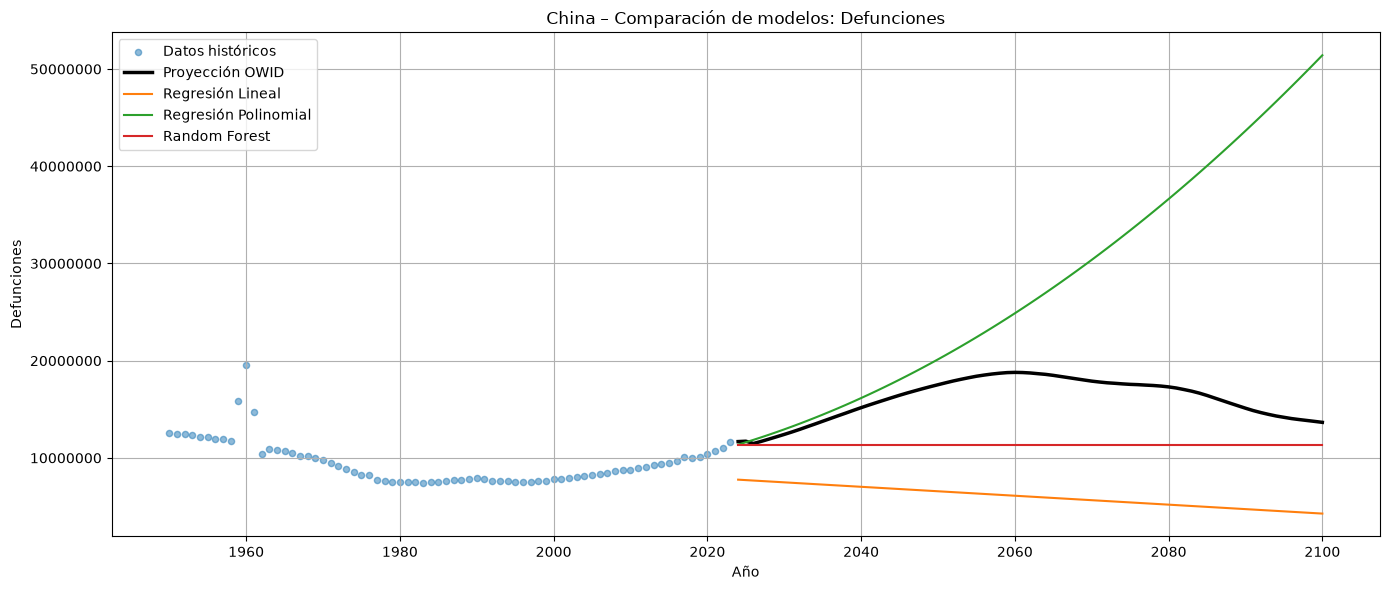

In [8]:
entrenar_y_graficar(df_china, titulo_pais="China")

# Ejercicio 2 – México desde 1980

In [9]:
df_mexico_1980 = df_raw[
    (df_raw["Entity"] == "Mexico") & (df_raw["Year"] >= 1980)
].copy()

df_mexico_1980.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22831,Mexico,MEX,1980,464115.0,NaN,2357249.0,NaN,2357249.0,464115.0
22832,Mexico,MEX,1981,461670.0,NaN,2366047.0,NaN,2366047.0,461670.0
22833,Mexico,MEX,1982,462853.0,NaN,2384613.0,NaN,2384613.0,462853.0
22834,Mexico,MEX,1983,465775.0,NaN,2404958.0,NaN,2404958.0,465775.0
22835,Mexico,MEX,1984,470587.0,NaN,2431036.0,NaN,2431036.0,470587.0


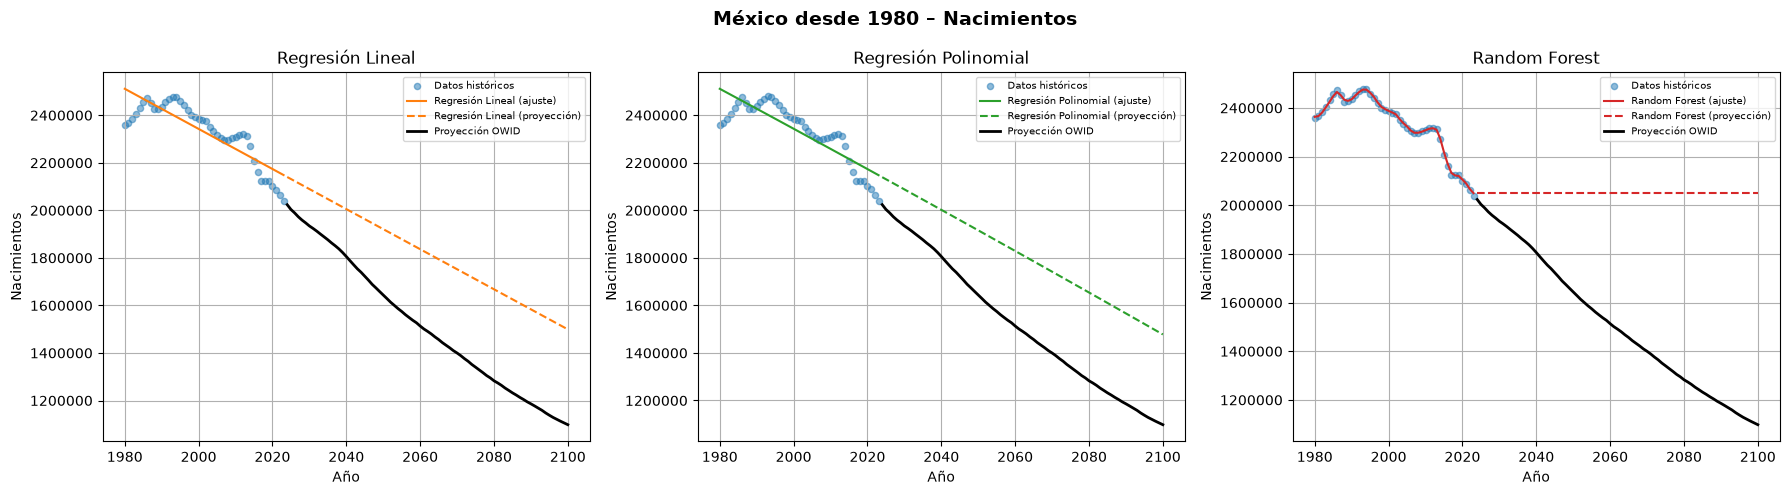

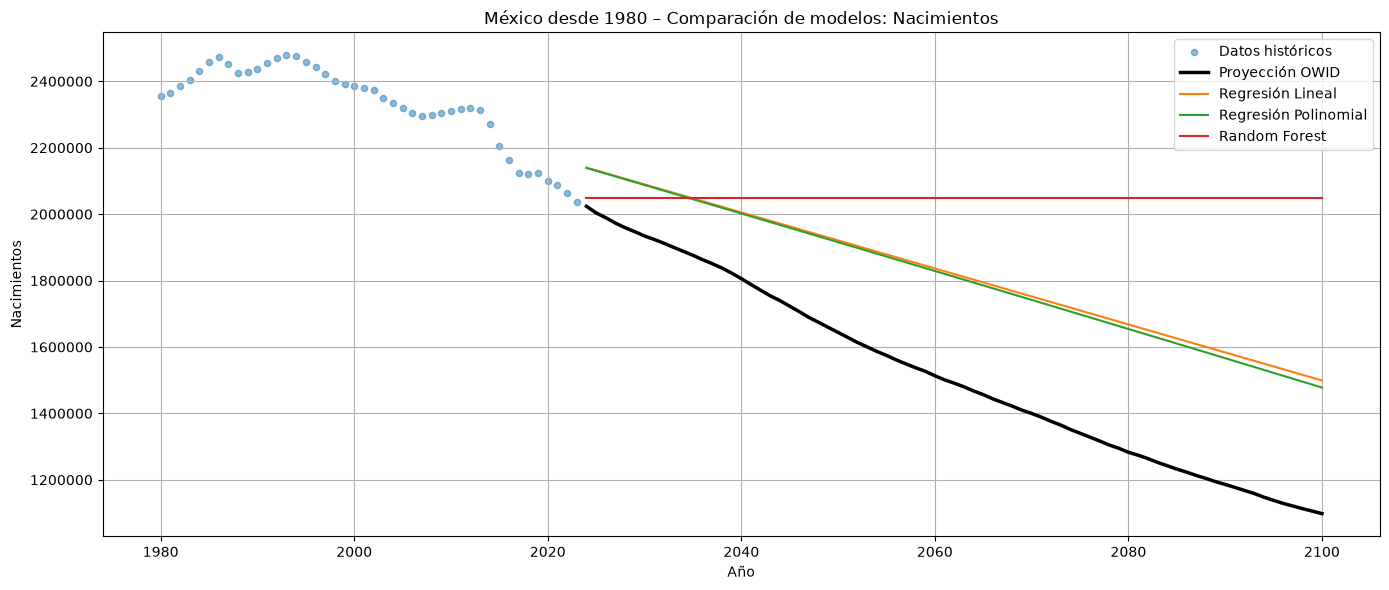

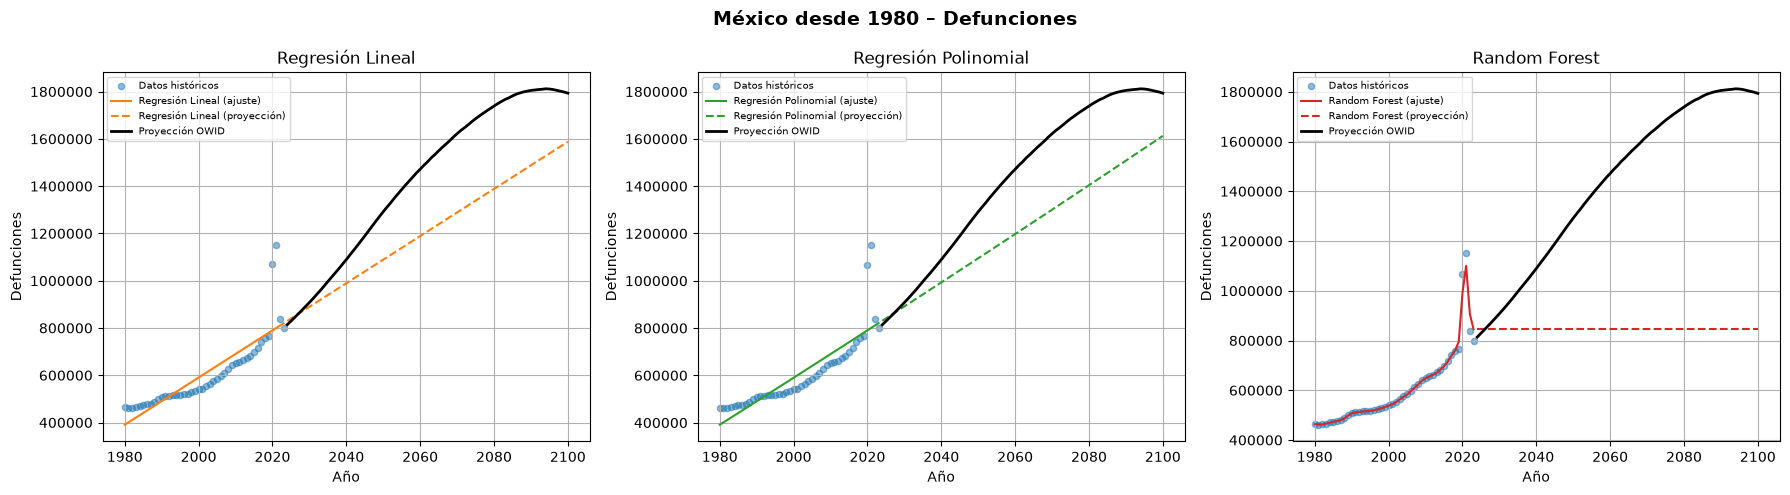

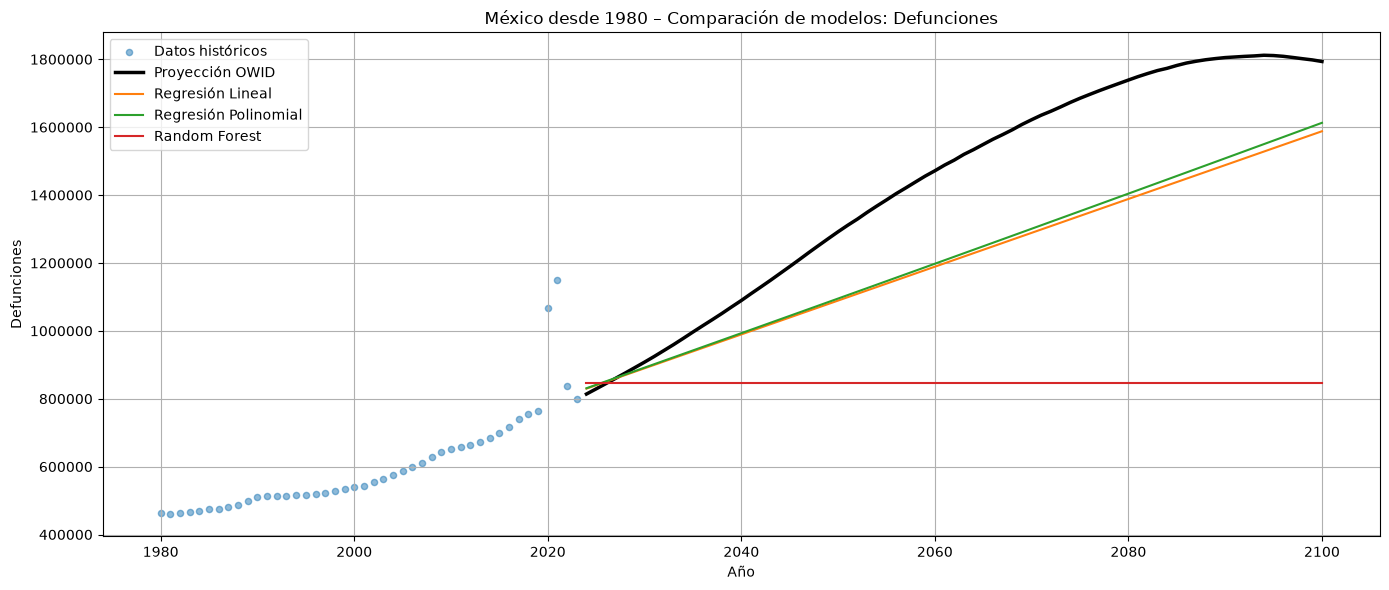

In [10]:
entrenar_y_graficar(df_mexico_1980, titulo_pais="México desde 1980")

# Ejercicio 3 – México desde 2000

In [11]:
df_mexico_2000 = df_raw[
    (df_raw["Entity"] == "Mexico") & (df_raw["Year"] >= 2000)
].copy()

df_mexico_2000.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22851,Mexico,MEX,2000,540567.0,NaN,2385977.0,NaN,2385977.0,540567.0
22852,Mexico,MEX,2001,543803.0,NaN,2380261.0,NaN,2380261.0,543803.0
22853,Mexico,MEX,2002,553391.0,NaN,2374140.0,NaN,2374140.0,553391.0
22854,Mexico,MEX,2003,563140.0,NaN,2351177.0,NaN,2351177.0,563140.0
22855,Mexico,MEX,2004,575925.0,NaN,2335226.0,NaN,2335226.0,575925.0


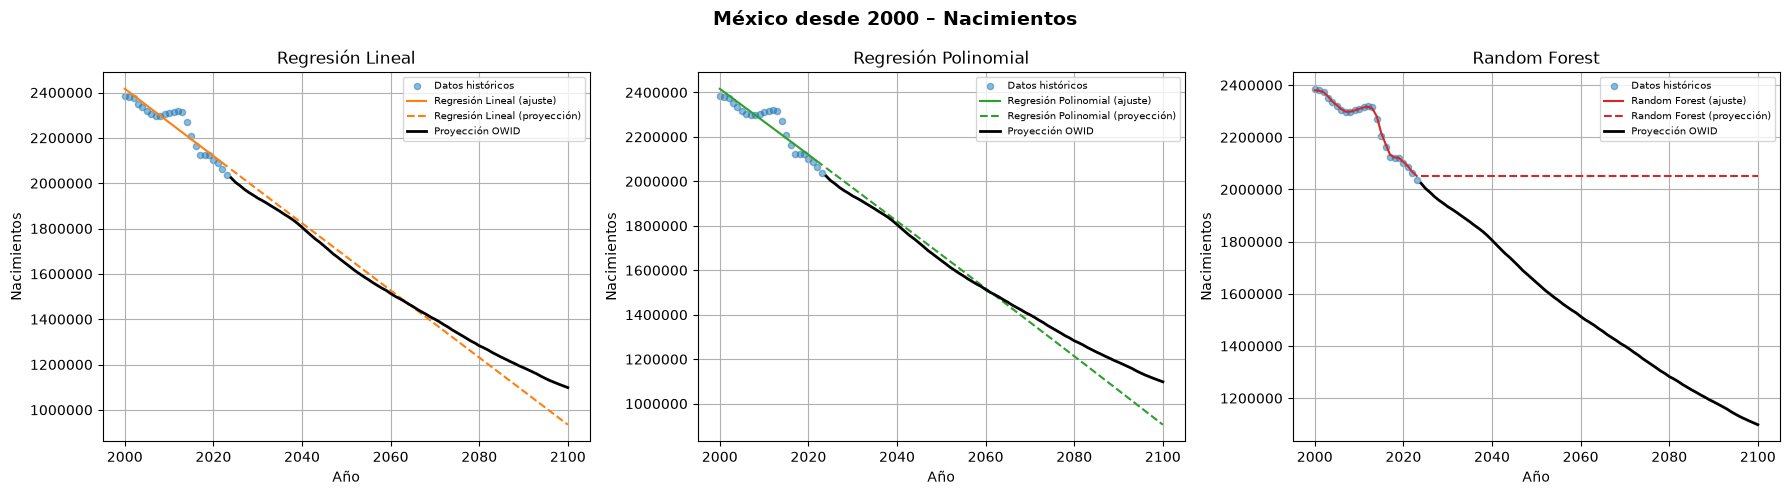

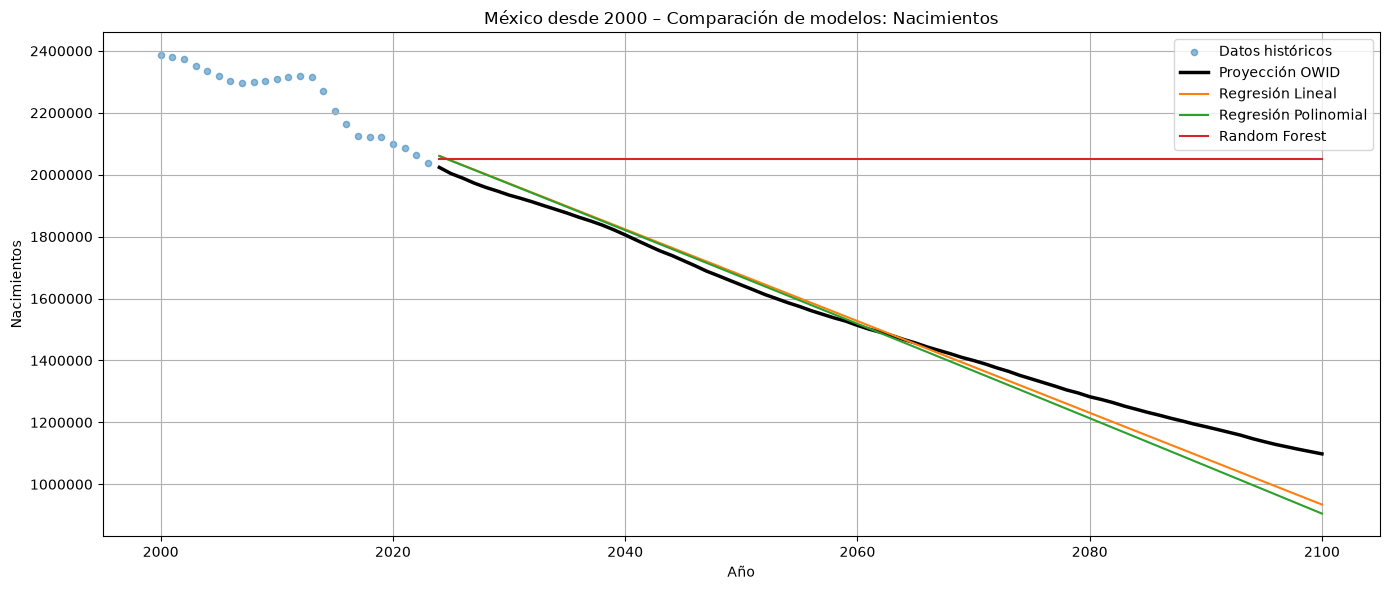

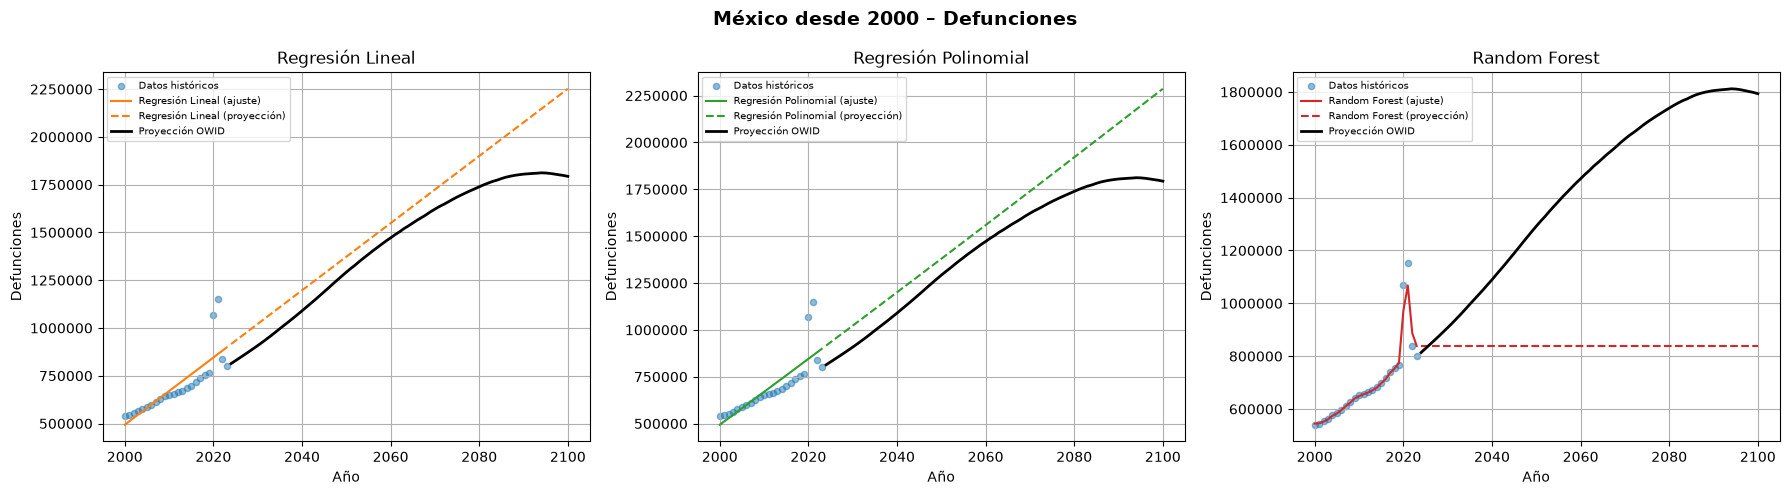

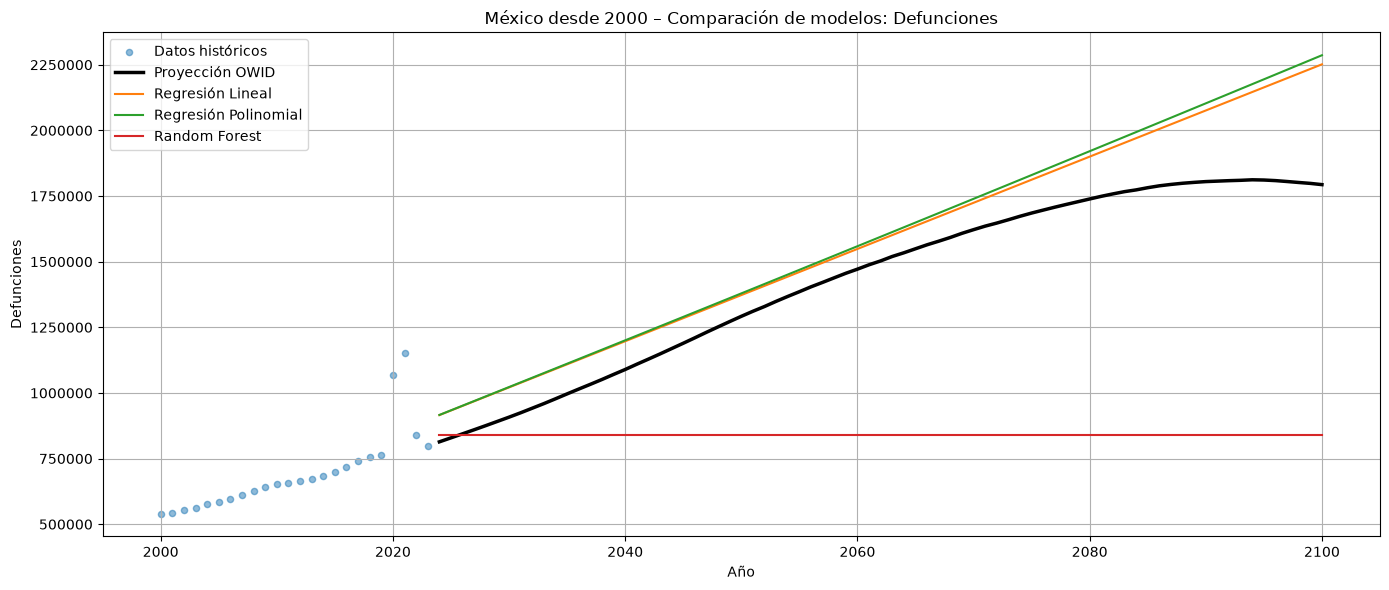

In [12]:
entrenar_y_graficar(df_mexico_2000, titulo_pais="México desde 2000")